# 08 - Augment TopN Videos

Generates augmented video files from the normalized clips produced by notebook 07.

Augmentations applied:
- temporal: slow down, speed up, frame interpolation, frame dropping
- spatial: shift (left/right/up/down), rotation, zoom in/out

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.style.use("ggplot")

print("Imports loaded. OpenCV:", cv2.__version__)

Imports loaded. OpenCV: 4.10.0


In [ ]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_topn_videos_normalized.csv"
OUTPUT_DIR = PROJECT_ROOT / "normalized_videos" / "topn_keepfps_224_gray_augmented"
OUTPUT_CSV = PROJECT_ROOT / "merged_datasets" / "universal_metadata_topn_videos_augmented.csv"

OVERWRITE = True
MAX_VIDEOS = None
SHUFFLE_BEFORE_LIMIT = True
RANDOM_SEED = 42
MAX_WORKERS = 12
GENERATE_VIDEOS = False

AUGMENTATIONS = [
    {"name": "slow_x0_8", "kind": "temporal_resample", "factor": 0.8},
    {"name": "fast_x1_25", "kind": "temporal_resample", "factor": 1.25},
    {"name": "interp_plus20", "kind": "temporal_resample", "factor": 1.0 / 1.2},
    {"name": "drop_every_5", "kind": "drop_stride", "stride": 5},
    {"name": "shift_left_8", "kind": "shift", "dx": -8, "dy": 0},
    {"name": "shift_right_8", "kind": "shift", "dx": 8, "dy": 0},
    {"name": "shift_up_8", "kind": "shift", "dx": 0, "dy": -8},
    {"name": "shift_down_8", "kind": "shift", "dx": 0, "dy": 8},
    {"name": "rot_left_5", "kind": "rotate", "angle": -5.0},
    {"name": "rot_right_5", "kind": "rotate", "angle": 5.0},
    {"name": "zoom_in_110", "kind": "zoom", "scale": 1.10},
    {"name": "zoom_out_90", "kind": "zoom", "scale": 0.90},
]

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Missing input CSV: {INPUT_CSV}")

print("INPUT_CSV:", INPUT_CSV)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("OUTPUT_CSV:", OUTPUT_CSV)
print("MAX_VIDEOS:", MAX_VIDEOS)
print("MAX_WORKERS:", MAX_WORKERS)
print("GENERATE_VIDEOS:", GENERATE_VIDEOS)
print("AUGMENTATIONS count:", len(AUGMENTATIONS))

INPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_videos_normalized.csv
OUTPUT_DIR: C:\Users\kacpe\source\repos\szum\normalized_videos\topn_keepfps_224_gray_augmented
OUTPUT_CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_videos_augmented.csv
MAX_VIDEOS: None
MAX_WORKERS: 12
GENERATE_VIDEOS: False
AUGMENTATIONS count: 12


In [3]:
def safe_fps(row: pd.Series) -> float:
    for key in ["normalized_fps", "fps", "input_fps"]:
        val = row.get(key, np.nan)
        try:
            f = float(val)
            if f > 1e-6:
                return f
        except Exception:
            pass
    return 30.0


def resolve_video_path(raw_path: str, project_root: Path) -> Path:
    p = Path(raw_path)
    if p.is_absolute():
        return p
    return project_root / p


def to_repo_path(absolute_path: Path, project_root: Path) -> str:
    try:
        return str(absolute_path.relative_to(project_root)).replace("\\", "/")
    except ValueError:
        return str(absolute_path).replace("\\", "/")


def read_video_frames(video_path: Path) -> list[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    frames: list[np.ndarray] = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)

    cap.release()
    return frames


def write_video(frames: list[np.ndarray], output_path: Path, fps: float) -> bool:
    if len(frames) == 0:
        return False

    h, w = frames[0].shape[:2]
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (w, h))
    if not writer.isOpened():
        return False

    try:
        for f in frames:
            writer.write(f)
    finally:
        writer.release()

    return True


def temporal_resample(frames: list[np.ndarray], factor: float) -> list[np.ndarray]:
    if len(frames) < 2:
        return frames

    n_in = len(frames)
    n_out = max(2, int(round(n_in / factor)))
    out: list[np.ndarray] = []

    for i in range(n_out):
        pos = i * (n_in - 1) / (n_out - 1)
        left = int(np.floor(pos))
        right = min(left + 1, n_in - 1)
        alpha = float(pos - left)

        if right == left:
            out.append(frames[left].copy())
        else:
            mixed = cv2.addWeighted(frames[left], 1.0 - alpha, frames[right], alpha, 0.0)
            out.append(mixed)

    return out


def drop_stride(frames: list[np.ndarray], stride: int) -> list[np.ndarray]:
    if len(frames) == 0:
        return frames
    out = [f for i, f in enumerate(frames) if (i + 1) % stride != 0]
    return out if len(out) > 0 else [frames[0]]


def shift_frame(frame: np.ndarray, dx: int, dy: int) -> np.ndarray:
    h, w = frame.shape[:2]
    m = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(frame, m, (w, h), borderMode=cv2.BORDER_REPLICATE)


def rotate_frame(frame: np.ndarray, angle: float) -> np.ndarray:
    h, w = frame.shape[:2]
    center = (w / 2.0, h / 2.0)
    m = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(frame, m, (w, h), borderMode=cv2.BORDER_REPLICATE)


def zoom_frame(frame: np.ndarray, scale: float) -> np.ndarray:
    h, w = frame.shape[:2]
    nh = max(1, int(round(h * scale)))
    nw = max(1, int(round(w * scale)))

    resized = cv2.resize(frame, (nw, nh), interpolation=cv2.INTER_LINEAR)

    if scale >= 1.0:
        y0 = (nh - h) // 2
        x0 = (nw - w) // 2
        return resized[y0:y0 + h, x0:x0 + w]

    out = np.zeros_like(frame)
    y0 = (h - nh) // 2
    x0 = (w - nw) // 2
    out[y0:y0 + nh, x0:x0 + nw] = resized
    return out


def apply_augmentation(frames: list[np.ndarray], aug: dict[str, Any]) -> list[np.ndarray]:
    kind = aug["kind"]

    if kind == "temporal_resample":
        return temporal_resample(frames, float(aug["factor"]))

    if kind == "drop_stride":
        return drop_stride(frames, int(aug["stride"]))

    if kind == "shift":
        dx = int(aug["dx"])
        dy = int(aug["dy"])
        return [shift_frame(f, dx, dy) for f in frames]

    if kind == "rotate":
        angle = float(aug["angle"])
        return [rotate_frame(f, angle) for f in frames]

    if kind == "zoom":
        scale = float(aug["scale"])
        return [zoom_frame(f, scale) for f in frames]

    raise ValueError(f"Unknown augmentation kind: {kind}")

In [4]:
df = pd.read_csv(INPUT_CSV)
required_cols = ["label", "normalized_video_path", "process_status"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

work_df = df[df["process_status"] == "ok"].copy()
work_df["normalized_video_path"] = work_df["normalized_video_path"].astype(str)
work_df = work_df[work_df["normalized_video_path"].str.len() > 0].copy()

if SHUFFLE_BEFORE_LIMIT:
    work_df = work_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

if MAX_VIDEOS is not None:
    work_df = work_df.head(int(MAX_VIDEOS)).copy()

print("Input rows total:", len(df))
print("Rows with process_status == ok:", len(work_df))
display(work_df[["label", "normalized_video_path"]].head(5))

Input rows total: 1647
Rows with process_status == ok: 1647


,label,normalized_video_path
0,student,normalized_videos/topn_keepfps_224_gray/studen...
1,doctor,normalized_videos/topn_keepfps_224_gray/doctor...
2,tired,normalized_videos/topn_keepfps_224_gray/tired/...
3,school,normalized_videos/topn_keepfps_224_gray/school...
4,finish,normalized_videos/topn_keepfps_224_gray/finish...


In [5]:
records = []

def process_base_video(idx: int, row: pd.Series) -> list[dict[str, Any]]:
    rows_out: list[dict[str, Any]] = []

    try:
        src_path = resolve_video_path(str(row["normalized_video_path"]), PROJECT_ROOT)
        label = str(row.get("label", "unknown"))
        fps = safe_fps(row)

        if not src_path.exists():
            base_fail = row.to_dict()
            base_fail.update({
                "is_augmented": False,
                "augmentation_name": "original",
                "augmented_video_path": "",
                "source_video_path": to_repo_path(src_path, PROJECT_ROOT),
                "aug_status": "missing_source",
                "aug_error": "Source file does not exist",
                "_row_idx": idx,
                "_order": 0,
            })
            rows_out.append(base_fail)
            return rows_out

        base_row = row.to_dict()
        base_row.update({
            "is_augmented": False,
            "augmentation_name": "original",
            "augmented_video_path": to_repo_path(src_path, PROJECT_ROOT),
            "source_video_path": to_repo_path(src_path, PROJECT_ROOT),
            "aug_status": "ok",
            "aug_error": "",
            "_row_idx": idx,
            "_order": 0,
        })
        rows_out.append(base_row)

        if GENERATE_VIDEOS:
            frames = read_video_frames(src_path)
            if len(frames) == 0:
                fail_row = row.to_dict()
                fail_row.update({
                    "is_augmented": True,
                    "augmentation_name": "all_failed",
                    "augmented_video_path": "",
                    "source_video_path": to_repo_path(src_path, PROJECT_ROOT),
                    "aug_status": "read_error",
                    "aug_error": "Cannot read source frames",
                    "_row_idx": idx,
                    "_order": 1,
                })
                rows_out.append(fail_row)
                return rows_out
        else:
            frames = []

        for aug_idx, aug in enumerate(AUGMENTATIONS, start=1):
            aug_name = str(aug["name"])
            out_name = f"{src_path.stem}____{aug_name}.mp4" # maintaining __ formatting pattern or _
            out_name = f"{src_path.stem}__{aug_name}.mp4"
            out_path = OUTPUT_DIR / label / out_name

            aug_row = row.to_dict()
            aug_row.update({
                "is_augmented": True,
                "augmentation_name": aug_name,
                "augmented_video_path": to_repo_path(out_path, PROJECT_ROOT),
                "source_video_path": to_repo_path(src_path, PROJECT_ROOT),
                "aug_status": "ok",
                "aug_error": "",
                "_row_idx": idx,
                "_order": aug_idx,
            })

            if not GENERATE_VIDEOS:
                rows_out.append(aug_row)
                continue

            if out_path.exists() and not OVERWRITE:
                rows_out.append(aug_row)
                continue

            try:
                aug_frames = apply_augmentation(frames, aug)
                ok = write_video(aug_frames, out_path, fps)
                if not ok:
                    aug_row["aug_status"] = "write_error"
                    aug_row["aug_error"] = "Cannot write output video"
            except Exception as exc:
                aug_row["aug_status"] = "transform_error"
                aug_row["aug_error"] = str(exc)

            rows_out.append(aug_row)

        return rows_out

    except Exception as exc:
        worker_fail = row.to_dict()
        worker_fail.update({
            "is_augmented": True,
            "augmentation_name": "worker_error",
            "augmented_video_path": "",
            "source_video_path": str(row.get("normalized_video_path", "")),
            "aug_status": "worker_error",
            "aug_error": str(exc),
            "_row_idx": idx,
            "_order": 9999,
        })
        rows_out.append(worker_fail)
        return rows_out

futures = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for idx, row in work_df.iterrows():
        futures.append(executor.submit(process_base_video, idx, row))

    done_count = 0
    total = len(futures)
    for future in as_completed(futures):
        records.extend(future.result())
        done_count += 1
        if done_count % 10 == 0 or done_count == total:
            print(f"Base video {done_count}/{total}")

aug_df = pd.DataFrame(records)
if "_row_idx" in aug_df.columns and "_order" in aug_df.columns:
    aug_df = aug_df.sort_values(["_row_idx", "_order"]).drop(columns=["_row_idx", "_order"]).reset_index(drop=True)

print("Rows in result:", len(aug_df))
display(aug_df.head(10))

Base video 10/1647
Base video 20/1647
Base video 30/1647
Base video 40/1647
Base video 50/1647
Base video 60/1647
Base video 70/1647
Base video 80/1647
Base video 90/1647
Base video 100/1647
Base video 110/1647
Base video 120/1647
Base video 130/1647
Base video 140/1647
Base video 150/1647
Base video 160/1647
Base video 170/1647
Base video 180/1647
Base video 190/1647
Base video 200/1647
Base video 210/1647
Base video 220/1647
Base video 230/1647
Base video 240/1647
Base video 250/1647
Base video 260/1647
Base video 270/1647
Base video 280/1647
Base video 290/1647
Base video 300/1647
Base video 310/1647
Base video 320/1647
Base video 330/1647
Base video 340/1647
Base video 350/1647
Base video 360/1647
Base video 370/1647
Base video 380/1647
Base video 390/1647
Base video 400/1647
Base video 410/1647
Base video 420/1647
Base video 430/1647
Base video 440/1647
Base video 450/1647
Base video 460/1647
Base video 470/1647
Base video 480/1647
Base video 490/1647
Base video 500/1647
Base vide

,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height,invalid_duration,invalid_fps,invalid_length_frames,duration_from_frames,consistency_error_sec,is_consistency_outlier,extreme_low_thr,extreme_high_thr,is_extreme_duration,is_anomaly,removal_reason,process_status,process_error,normalized_video_path,input_fps,normalized_fps,input_width,input_height,normalized_width,normalized_height,input_frame_count,normalized_frame_count,input_duration_sec,normalized_duration_sec,normalized_color_mode,is_augmented,augmentation_name,augmented_video_path,source_video_path,aug_status,aug_error
0,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,False,original,normalized_videos/topn_keepfps_224_gray/studen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
1,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,True,slow_x0_8,normalized_videos/topn_keepfps_224_gray_augmen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
2,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,True,fast_x1_25,normalized_videos/topn_keepfps_224_gray_augmen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
3,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,True,interp_plus20,normalized_videos/topn_keepfps_224_gray_augmen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
4,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,True,drop_every_5,normalized_videos/topn_keepfps_224_gray_augmen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
5,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,True,shift_left_8,normalized_videos/topn_keepfps_224_gray_augmen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
6,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen...,29.97003,29.97003,640,360,224,224,1610,1610,53.720333,53.720333,grayscale,True,shift_right_8,normalized_videos/topn_keepfps_224_gray_augmen...,normalized_videos/topn_keepfps_224_gray/studen...,ok,
7,student,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IeH7XYbo0yg...,316,396.0,81.0,2.669,29.97,msasl_140,True,1280.0,720.0,False,False,False,2.702703,0.033703,False,0.467,8.125,False,False,NaN,ok,NaN,normalized_videos/topn_keepfps_224_gray/studen..

,count
aug_status,
ok,21411


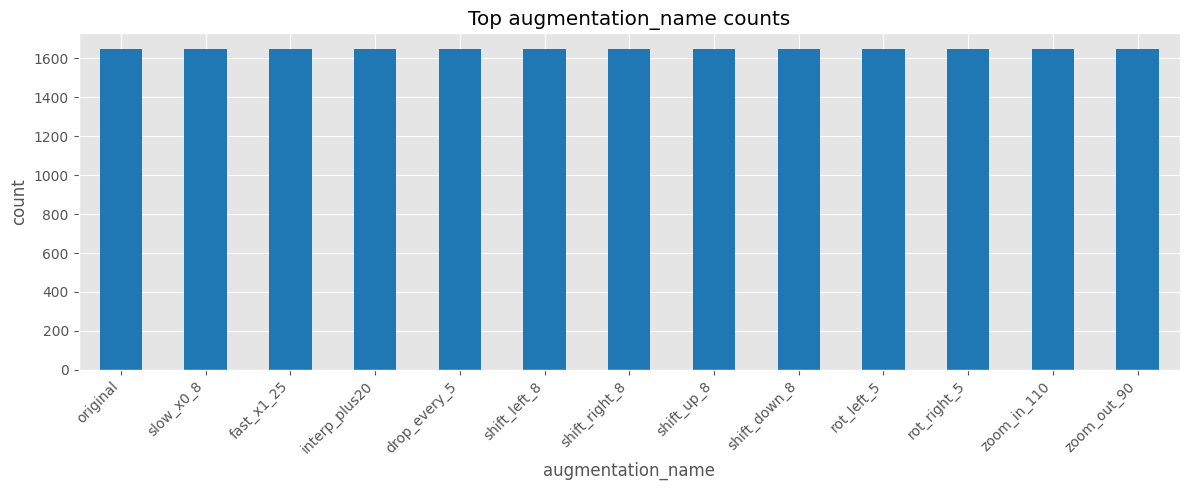

In [6]:
status_counts = aug_df["aug_status"].value_counts(dropna=False)
display(status_counts.to_frame("count"))

aug_counts = aug_df["augmentation_name"].value_counts(dropna=False).head(20)
fig, ax = plt.subplots(figsize=(12, 5))
aug_counts.plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_title("Top augmentation_name counts")
ax.set_xlabel("augmentation_name")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
aug_df.to_csv(OUTPUT_CSV, index=False)

print("Saved augmented CSV:", OUTPUT_CSV)
print("Saved augmented videos root:", OUTPUT_DIR)

preview_cols = [
    "label",
    "is_augmented",
    "augmentation_name",
    "augmented_video_path",
    "aug_status",
]
display(aug_df[preview_cols].head(15))

Saved augmented CSV: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_topn_videos_augmented.csv
Saved augmented videos root: C:\Users\kacpe\source\repos\szum\normalized_videos\topn_keepfps_224_gray_augmented


,label,is_augmented,augmentation_name,augmented_video_path,aug_status
0,student,False,original,normalized_videos/topn_keepfps_224_gray/studen...,ok
1,student,True,slow_x0_8,normalized_videos/topn_keepfps_224_gray_augmen...,ok
2,student,True,fast_x1_25,normalized_videos/topn_keepfps_224_gray_augmen...,ok
3,student,True,interp_plus20,normalized_videos/topn_keepfps_224_gray_augmen...,ok
4,student,True,drop_every_5,normalized_videos/topn_keepfps_224_gray_augmen...,ok
5,student,True,shift_left_8,normalized_videos/topn_keepfps_224_gray_augmen...,ok
6,student,True,shift_right_8,normalized_videos/topn_keepfps_224_gray_augmen...,ok
7,student,True,shift_up_8,normalized_videos/topn_keepfps_224_gray_augmen...,ok
8,student,True,shift_down_8,normalized_videos/topn_keepfps_224_gray_augmen...,ok
9,student,True,rot_left_5,normalized_videos/topn_keepfps_224_gray_augmen...,ok
